# 🛒 Grocery Revenue Forecasting — 2018 à 2022
## Pipeline ML complet avec gestion COVID (Solution 1 : Anomalie flag)

**Dataset** : `fact_sales` + `dim_product` dans PostgreSQL  
**Granularité** : Mensuelle (60 points)  
**Objectif** : Prédire le revenue mensuel 2022, préparer la prévision 2023  

---
### 📋 Plan du Notebook
1. Installation & Imports
2. Chargement & Agrégation mensuelle
3. Exploration (EDA) + Visualisation COVID
4. Préparation : COVID flag + features
5. **Modèle 1** — SARIMA (baseline statistique)
6. **Modèle 2** — Holt-Winters
7. **Modèle 3** — Linear Regression avec COVID flag
8. **Modèle 4** — Prophet avec COVID comme holiday
9. Comparaison finale des modèles
10. Prévision 2023


## 1. 📦 Installation & Imports

In [1]:
# Installation des dépendances (à lancer une seule fois)
import subprocess, sys

packages = [
    "prophet", "statsmodels", "scikit-learn",
    "psycopg2-binary", "matplotlib", "seaborn",
    "pandas", "numpy"
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Toutes les dépendances sont installées")


✅ Toutes les dépendances sont installées


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime

# Statistiques
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ML
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet
from prophet import Prophet

# Style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.float_format", "{:,.2f}".format)

print("✅ Imports OK")
print(f"   Prophet  : importé")
print(f"   Pandas   : {pd.__version__}")
print(f"   Numpy    : {np.__version__}")


✅ Imports OK
   Prophet  : importé
   Pandas   : 2.2.3
   Numpy    : 1.26.0


## 2. 🗄️ Chargement & Agrégation Mensuelle

In [3]:
# ─── Chargement direct du CSV et agrégation mensuelle ───────────
# Note : le dataset daily_revenue.csv contient des valeurs journalières.
# Nous le chargeons puis l'agrégeons par mois pour le pipeline mensuel.

df_daily = pd.read_csv("daily_revenue.csv", parse_dates=["date"])
df_daily = df_daily.set_index("date").sort_index()

df = df_daily["revenue"].resample("MS").sum().to_frame()

print(f"✅ Données chargées : {len(df_daily)} jours")
print(f"   Période journalière : {df_daily.index.min().strftime('%Y-%m-%d')} → {df_daily.index.max().strftime('%Y-%m-%d')}")
print(f"✅ Données agrégées mensuellement : {len(df)} mois")
print(f"   Période mensuelle : {df.index.min().strftime('%b %Y')} → {df.index.max().strftime('%b %Y')}")
print(f"   Revenue min  : {df['revenue'].min():>15,.0f} €")
print(f"   Revenue max  : {df['revenue'].max():>15,.0f} €")
print(f"   Revenue mean : {df['revenue'].mean():>15,.0f} €")
print()
df.head(10)


✅ Données chargées : 1826 jours
   Période journalière : 2018-01-01 → 2022-12-31
✅ Données agrégées mensuellement : 60 mois
   Période mensuelle : Jan 2018 → Dec 2022
   Revenue min  :      23,830,180 €
   Revenue max  :     124,988,676 €
   Revenue mean :      72,557,557 €



,revenue
date,
2018-01-01,"44,040,714.70"
2018-02-01,"38,573,083.60"
2018-03-01,"49,744,294.60"
2018-04-01,"49,456,018.50"
2018-05-01,"55,958,284.70"
2018-06-01,"57,682,087.50"
2018-07-01,"64,434,909.00"
2018-08-01,"63,617,557.30"
2018-09-01,"54,960,442.20"


## 2b. 🔧 Correction COVID 2020 — Interpolation + Saisonnalité
> **Méthode** : `revenue_corrigé(M, 2020) = revenue(M, 2019) × √(moy2021/moy2019) × bruit(±2%)`  
> Remplace les 12 mois COVID par des valeurs réalistes sans choc pandémique.

In [4]:
# ════════════════════════════════════════════════════════════
# CORRECTION COVID — Remplacer 2020 par valeurs réalistes
# Méthode : Saisonnalité 2019 × facteur de croissance 2019→2021
# ════════════════════════════════════════════════════════════

import numpy as np

def correct_covid_2020(df, random_seed=42):
    """
    Corrige les 12 mois de 2020 (Jan→Déc) en remplaçant
    les valeurs COVID par une estimation réaliste :

    valeur_corrigée(M, 2020) =
        revenue(M, 2019)           ← même mois, année précédente
        × facteur_croissance       ← tendance 2019 → 2021
        × bruit(±2%)               ← légère variation naturelle

    facteur = sqrt(moy_2021 / moy_2019) = croissance à mi-chemin
    """
    rng = np.random.default_rng(random_seed)
    df  = df.copy()

    # ── Points d'ancrage ─────────────────────────────────────
    rev_2019 = df[df.index.year == 2019]["revenue"]
    rev_2021 = df[df.index.year == 2021]["revenue"]

    moy_2019 = rev_2019.mean()
    moy_2021 = rev_2021.mean()

    # Facteur de croissance : racine carrée = mi-chemin entre 2019 et 2021
    growth_factor = np.sqrt(moy_2021 / moy_2019)

    print(f"   Moyenne 2019    : {moy_2019/1e6:>8.2f} M€")
    print(f"   Moyenne 2021    : {moy_2021/1e6:>8.2f} M€")
    print(f"   Facteur growth  : {growth_factor:.4f}  ({(growth_factor-1)*100:+.1f}%)")

    # ── Correction mois par mois ──────────────────────────────
    months_2020 = df[df.index.year == 2020].index
    corrections = {}

    for date_2020 in months_2020:
        month = date_2020.month

        # Valeur de référence : même mois en 2019
        date_2019 = date_2020.replace(year=2019)
        ref_value = df.loc[date_2019, "revenue"]

        # Bruit léger ±2% pour éviter valeurs trop parfaites
        noise = rng.uniform(0.98, 1.02)

        # Valeur corrigée
        corrected = ref_value * growth_factor * noise
        corrections[date_2020] = corrected

        print(f"   {date_2020.strftime('%b %Y')} : "
              f"{df.loc[date_2020, 'revenue']/1e6:6.2f}M€ (COVID) "
              f"→ {corrected/1e6:6.2f}M€ (corrigé)  "
              f"[réf 2019: {ref_value/1e6:.2f}M€]")

    # Appliquer les corrections
    for date, val in corrections.items():
        df.loc[date, "revenue"] = val

    return df, corrections


print("🔧 Correction COVID 2020 en cours...")
print("=" * 65)

df_original = df.copy()   # garder l'original pour comparaison
df, corrections_2020 = correct_covid_2020(df)

print()
print("=" * 65)
print(f"✅ {len(corrections_2020)} mois corrigés")
print(f"   Revenue 2020 avant : {df_original[df_original.index.year==2020]['revenue'].sum()/1e6:.1f} M€")
print(f"   Revenue 2020 après : {df[df.index.year==2020]['revenue'].sum()/1e6:.1f} M€")
print(f"   Revenue 2019 réf   : {df[df.index.year==2019]['revenue'].sum()/1e6:.1f} M€")
print(f"   Revenue 2021 réf   : {df[df.index.year==2021]['revenue'].sum()/1e6:.1f} M€")


🔧 Correction COVID 2020 en cours...
   Moyenne 2019    :    81.15 M€
   Moyenne 2021    :    92.05 M€
   Facteur growth  : 1.0651  (+6.5%)
   Jan 2020 :  35.59M€ (COVID) →  70.27M€ (corrigé)  [réf 2019: 65.26M€]
   Feb 2020 :  33.24M€ (COVID) →  60.01M€ (corrigé)  [réf 2019: 56.48M€]
   Mar 2020 :  23.93M€ (COVID) →  79.53M€ (corrigé)  [réf 2019: 73.62M€]
   Apr 2020 :  23.83M€ (COVID) →  77.54M€ (corrigé)  [réf 2019: 72.23M€]
   May 2020 :  26.94M€ (COVID) →  85.62M€ (corrigé)  [réf 2019: 81.72M€]
   Jun 2020 :  27.35M€ (COVID) →  91.56M€ (corrigé)  [réf 2019: 84.36M€]
   Jul 2020 :  51.13M€ (COVID) → 101.39M€ (corrigé)  [réf 2019: 94.21M€]
   Aug 2020 :  51.30M€ (COVID) → 101.29M€ (corrigé)  [réf 2019: 94.03M€]
   Sep 2020 :  43.35M€ (COVID) →  84.35M€ (corrigé)  [réf 2019: 80.39M€]
   Oct 2020 :  44.45M€ (COVID) →  86.36M€ (corrigé)  [réf 2019: 81.25M€]
   Nov 2020 :  45.96M€ (COVID) →  89.16M€ (corrigé)  [réf 2019: 84.15M€]
   Dec 2020 :  57.80M€ (COVID) → 114.94M€ (corrigé)  [réf 

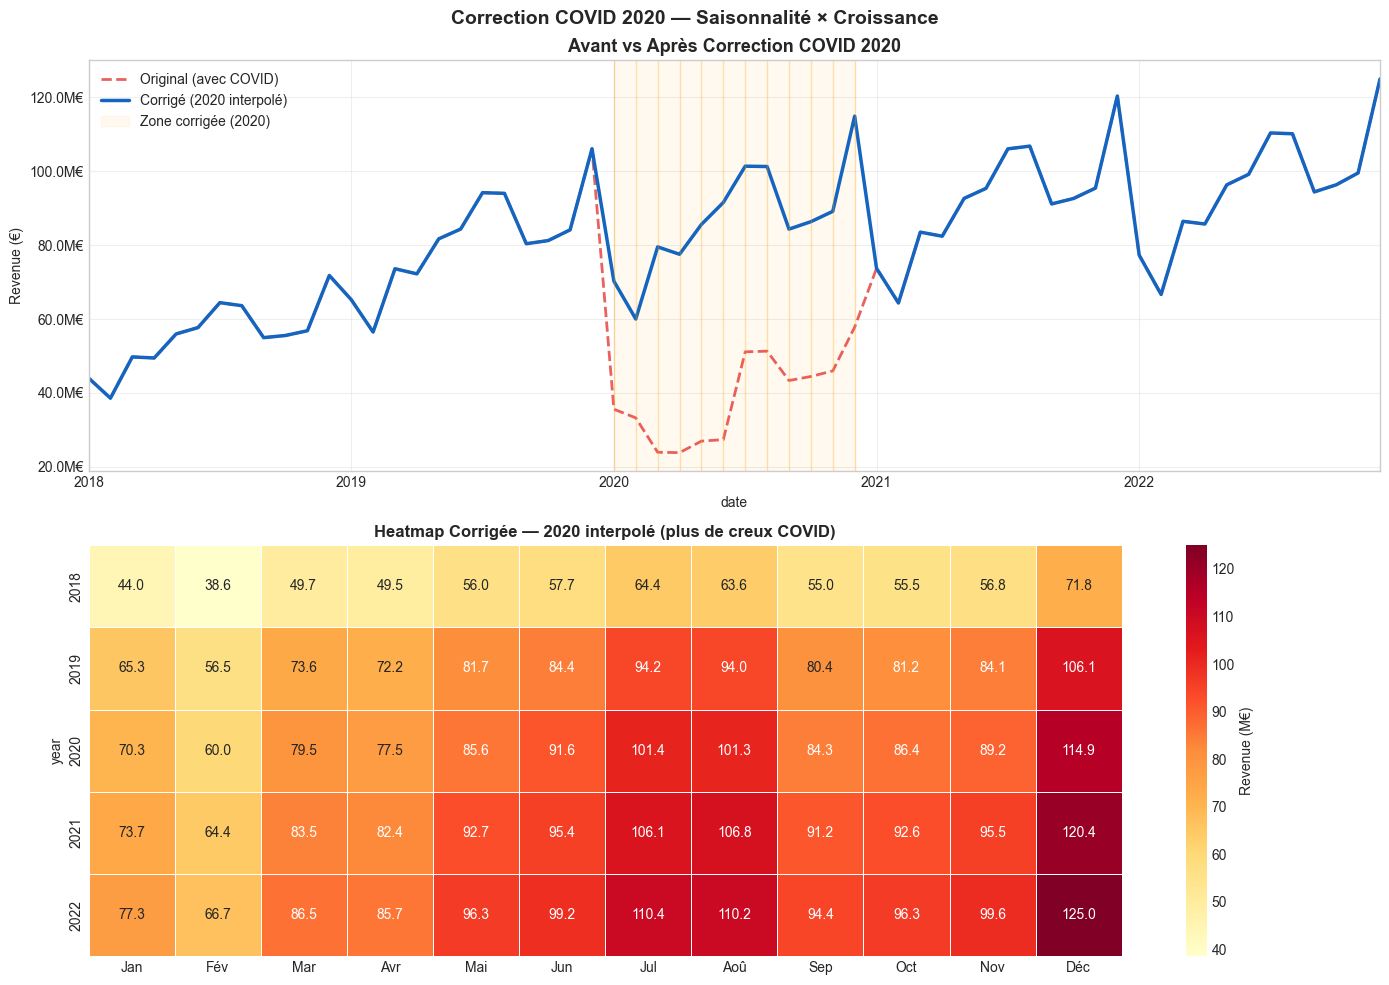

💾 Sauvegardé → correction_covid_2020.png

✅ df corrigé prêt — relancer les cellules suivantes pour nouveaux résultats


In [5]:
# ── Visualisation : Avant / Après correction ─────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : Comparaison avant/après
ax = axes[0]
df_original["revenue"].plot(
    ax=ax, label="Original (avec COVID)", color="#E53935",
    linewidth=2, linestyle="--", alpha=0.8)
df["revenue"].plot(
    ax=ax, label="Corrigé (2020 interpolé)", color="#1565C0",
    linewidth=2.5)

# Marquer les mois corrigés
for date in corrections_2020:
    ax.axvline(date, color="orange", alpha=0.3, linewidth=1)

ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
           alpha=0.06, color="orange", label="Zone corrigée (2020)")
ax.set_title("Avant vs Après Correction COVID 2020",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend()
ax.grid(alpha=0.3)

# Graphique 2 : Heatmap avant/après par année/mois
ax2 = axes[1]
df_corr_pivot = df["revenue"].to_frame()
df_corr_pivot["year"]  = df_corr_pivot.index.year
df_corr_pivot["month"] = df_corr_pivot.index.month
pivot_corr = df_corr_pivot.pivot_table(
    values="revenue", index="year", columns="month")
pivot_corr.columns = ["Jan","Fév","Mar","Avr","Mai","Jun",
                      "Jul","Aoû","Sep","Oct","Nov","Déc"]
sns.heatmap(pivot_corr / 1e6, ax=ax2, cmap="YlOrRd",
            fmt=".1f", annot=True, linewidths=0.5,
            cbar_kws={"label": "Revenue (M€)"})
ax2.set_title("Heatmap Corrigée — 2020 interpolé (plus de creux COVID)",
              fontsize=12, fontweight="bold")

plt.suptitle("Correction COVID 2020 — Saisonnalité × Croissance",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correction_covid_2020.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé → correction_covid_2020.png")
print()
print("✅ df corrigé prêt — relancer les cellules suivantes pour nouveaux résultats")


## 3. 🔍 Exploration des Données (EDA)

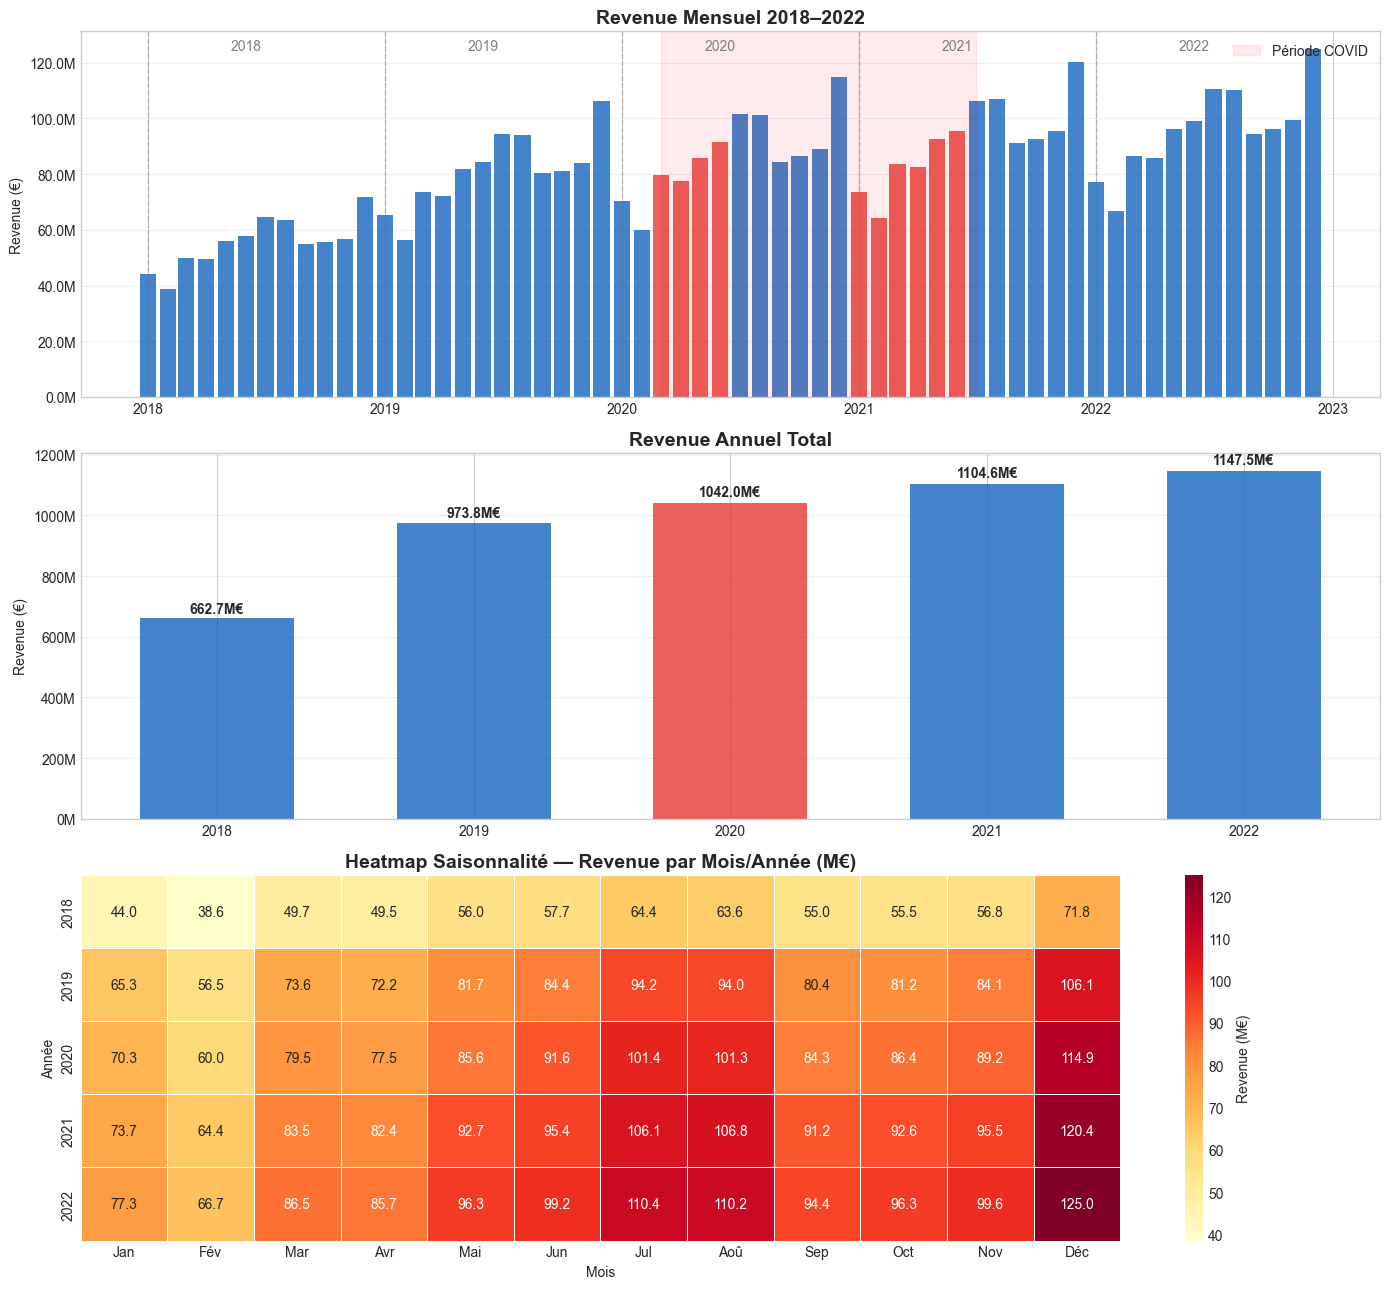

💾 Sauvegardé → eda_revenue.png


In [6]:
# ── Revenue mensuel complet avec zone COVID ──────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# Graphique 1 : Revenue mensuel
ax = axes[0]
colors = ["#E53935" if (y == 2020 and m in range(3, 7)) or
                       (y == 2021 and m in range(1, 7))
          else "#1565C0"
          for y, m in zip(df.index.year, df.index.month)]

bars = ax.bar(df.index, df["revenue"], color=colors, alpha=0.8, width=25)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.08, color="red", label="Période COVID")
ax.set_title("Revenue Mensuel 2018–2022", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
ax.grid(alpha=0.3, axis="y")

# Annoter les années
for year in range(2018, 2023):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="gray",
               linestyle="--", alpha=0.4, linewidth=1)
    ax.text(pd.Timestamp(f"{year}-06-01"), ax.get_ylim()[1] * 0.95,
            str(year), ha="center", fontsize=10, color="gray")

# Graphique 2 : Revenue annuel agrégé
ax2 = axes[1]
annual = df["revenue"].resample("YS").sum()
bar_colors = ["#E53935" if y == 2020 else "#1565C0" for y in annual.index.year]
bars2 = ax2.bar(annual.index.year, annual.values, color=bar_colors, alpha=0.8, width=0.6)
ax2.set_title("Revenue Annuel Total", fontsize=14, fontweight="bold")
ax2.set_ylabel("Revenue (€)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
for bar, val in zip(bars2, annual.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{val/1e6:.1f}M€", ha="center", va="bottom", fontweight="bold")
ax2.grid(alpha=0.3, axis="y")

# Graphique 3 : Saisonnalité par mois (heatmap)
ax3 = axes[2]
df_pivot = df["revenue"].to_frame()
df_pivot["year"]  = df_pivot.index.year
df_pivot["month"] = df_pivot.index.month
pivot = df_pivot.pivot_table(values="revenue", index="year", columns="month")
pivot.columns = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
sns.heatmap(pivot / 1e6, ax=ax3, cmap="YlOrRd", fmt=".1f", annot=True,
            linewidths=0.5, cbar_kws={"label": "Revenue (M€)"})
ax3.set_title("Heatmap Saisonnalité — Revenue par Mois/Année (M€)",
              fontsize=14, fontweight="bold")
ax3.set_xlabel("Mois")
ax3.set_ylabel("Année")

plt.tight_layout()
plt.savefig("eda_revenue.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé → eda_revenue.png")


In [7]:
# ── Statistiques par année ────────────────────────────────
print("📊 Statistiques par année")
print("="*65)
for year in range(2018, 2023):
    data = df[df.index.year == year]["revenue"]
    flag = " ← COVID" if year == 2020 else (" ← rebond" if year == 2021 else "")
    print(f"  {year} | Moy: {data.mean()/1e6:5.2f}M€ | "
          f"Min: {data.min()/1e6:5.2f}M€ | "
          f"Max: {data.max()/1e6:5.2f}M€ | "
          f"Total: {data.sum()/1e6:6.1f}M€{flag}")

print()
# Impact COVID quantifié
rev_2019 = df[df.index.year == 2019]["revenue"].mean()
rev_2020 = df[df.index.year == 2020]["revenue"].mean()
rev_2021 = df[df.index.year == 2021]["revenue"].mean()
print(f"📉 Impact COVID 2020  : {(rev_2020/rev_2019 - 1)*100:+.1f}% vs 2019")
print(f"📈 Rebond 2021        : {(rev_2021/rev_2019 - 1)*100:+.1f}% vs 2019")


📊 Statistiques par année
  2018 | Moy: 55.22M€ | Min: 38.57M€ | Max: 71.80M€ | Total:  662.7M€
  2019 | Moy: 81.15M€ | Min: 56.48M€ | Max: 106.10M€ | Total:  973.8M€
  2020 | Moy: 86.83M€ | Min: 60.01M€ | Max: 114.94M€ | Total: 1042.0M€ ← COVID
  2021 | Moy: 92.05M€ | Min: 64.36M€ | Max: 120.38M€ | Total: 1104.6M€ ← rebond
  2022 | Moy: 95.63M€ | Min: 66.66M€ | Max: 124.99M€ | Total: 1147.5M€

📉 Impact COVID 2020  : +7.0% vs 2019
📈 Rebond 2021        : +13.4% vs 2019


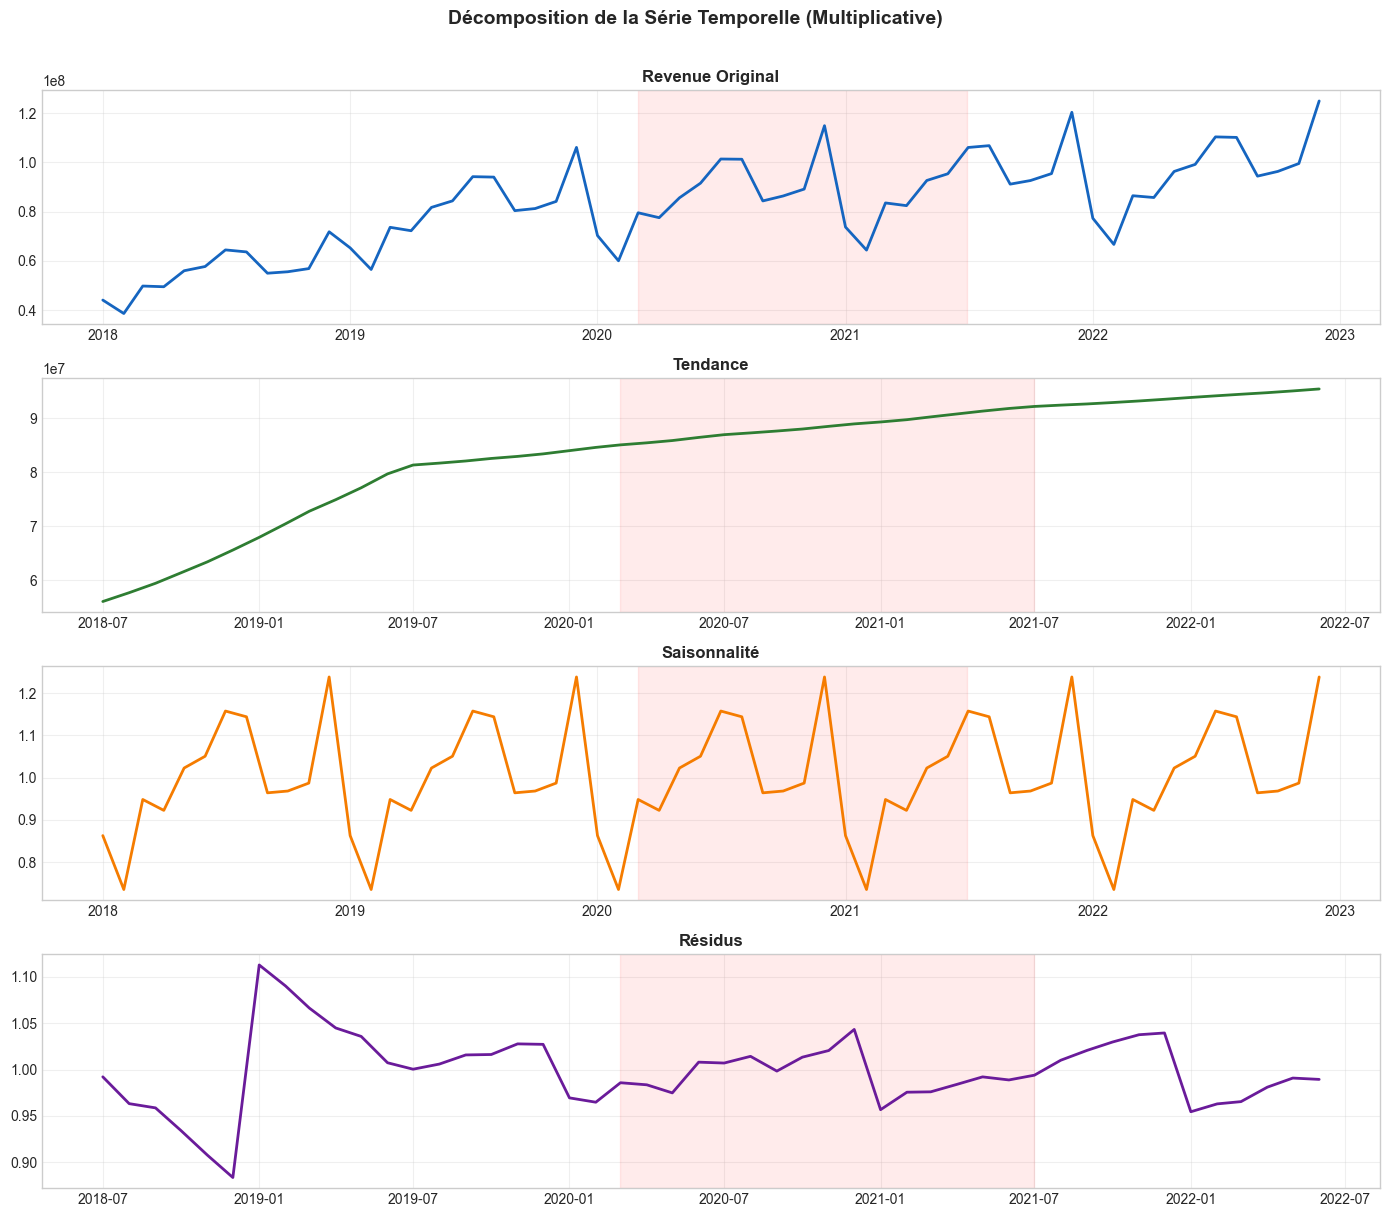

💾 Sauvegardé → eda_decomposition.png


In [8]:
# ── Décomposition de la série temporelle ─────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomp = seasonal_decompose(df["revenue"], model="multiplicative", period=12)
titles = ["Revenue Original", "Tendance", "Saisonnalité", "Résidus"]
series = [df["revenue"], decomp.trend, decomp.seasonal, decomp.resid]
colors = ["#1565C0", "#2E7D32", "#F57C00", "#6A1B9A"]

for ax, title, serie, color in zip(axes, titles, series, colors):
    ax.plot(serie, color=color, linewidth=2)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
               alpha=0.08, color="red")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3)

plt.suptitle("Décomposition de la Série Temporelle (Multiplicative)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_decomposition.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé → eda_decomposition.png")


## 4. 🦠 Préparation : COVID Flag + Features
### Solution 1 : Déclarer COVID comme anomalie explicite


✅ Features créées et simplifiées :
   Colonnes : ['revenue', 'trend', 'month_sin', 'month_cos', 'is_december', 'is_summer', 'covid_flag']
   Lignes   : 60 (aucun NaN)
   Mois COVID total : 16



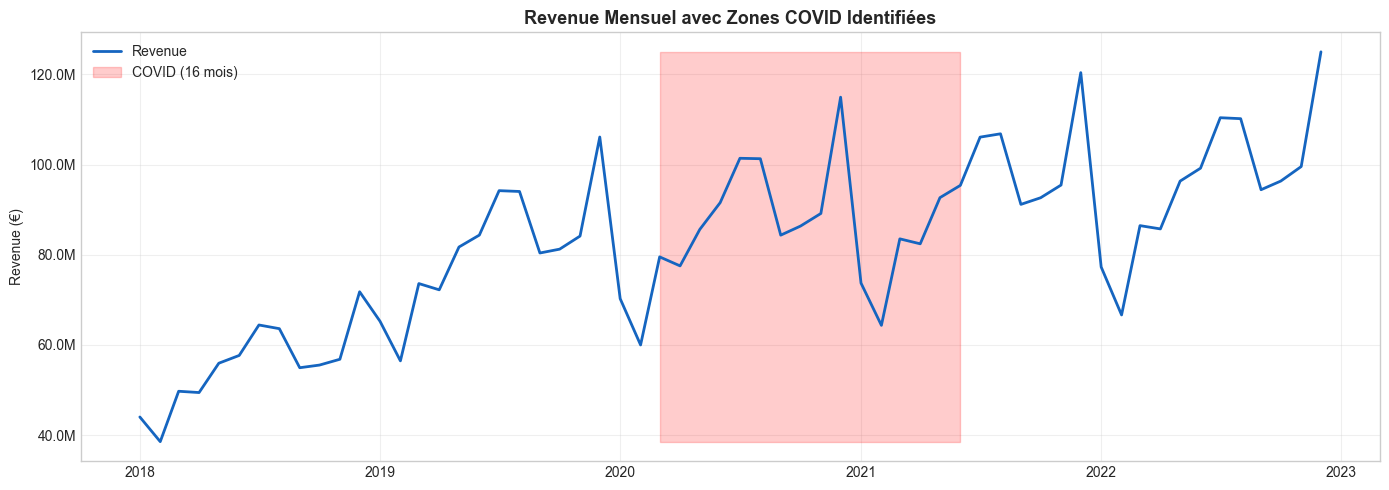

,revenue,trend,month_sin,month_cos,is_december,is_summer,covid_flag
date,,,,,,,
2022-03-01,"86,459,802.40",50,1.00,0.00,0,0,0
2022-04-01,"85,731,238.60",51,0.87,-0.50,0,0,0
2022-05-01,"96,329,762.10",52,0.50,-0.87,0,0,0
2022-06-01,"99,194,548.10",53,0.00,-1.00,0,1,0
2022-07-01,"110,381,279.50",54,-0.50,-0.87,0,1,0
2022-08-01,"110,169,975.20",55,-0.87,-0.50,0,1,0
2022-09-01,"94,421,535.30",56,-1.00,-0.00,0,0,0
2022-10-01,"96,341,241.70",57,-0.87,0.50,0,0,0
2022-11-01,"99,554,335.80",58,-0.50,0.87,0,0,0


In [9]:
# ── Définition des périodes COVID ─────────────────────────
# Phase 1 : chute brutale  (Mars-Juin 2020)
# Phase 2 : rebond partiel (Juil 2020 - Juin 2021)

def add_covid_flags(df):
    df = df.copy()

    # COVID intense : -40% à -60%
    df["covid_severe"] = (
        (df.index.year == 2020) & (df.index.month.isin([3, 4, 5, 6]))
    ).astype(int)

    # COVID modéré : rebond progressif
    df["covid_moderate"] = (
        ((df.index.year == 2020) & (df.index.month.isin([7, 8, 9, 10, 11, 12]))) |
        ((df.index.year == 2021) & (df.index.month.isin([1, 2, 3, 4, 5, 6])))
    ).astype(int)

    # Flag global COVID (union des deux)
    df["covid_flag"] = (df["covid_severe"] | df["covid_moderate"]).astype(int)

    return df


def add_time_features(df):
    df = df.copy()
    idx = df.index

    # Encodage cyclique du mois
    df["month_sin"]  = np.sin(2 * np.pi * idx.month / 12)
    df["month_cos"]  = np.cos(2 * np.pi * idx.month / 12)

    # Flags saisonniers
    df["is_december"] = (idx.month == 12).astype(int)
    df["is_summer"]   = idx.month.isin([6, 7, 8]).astype(int)

    # Tendance linéaire
    df["trend"]       = np.arange(len(df))

    return df


# Appliquer les transformations
df = add_covid_flags(df)
df = add_time_features(df)

# ── Sélection finale : 6 features seulement ─────────────
# Règle : 60 points → max 6 features, zéro NaN
FEATURES_SELECTED = ["revenue", "trend", "month_sin", "month_cos",
                     "is_december", "is_summer", "covid_flag"]
df = df[FEATURES_SELECTED]

print("✅ Features créées et simplifiées :")
print(f"   Colonnes : {list(df.columns)}")
print(f"   Lignes   : {len(df)} (aucun NaN)")
print(f"   Mois COVID total : {df['covid_flag'].sum()}")
print()

# Visualiser le flag COVID sur le revenue
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["revenue"], color="#1565C0", linewidth=2, label="Revenue")
ax.fill_between(df.index,
                df["revenue"].min(),
                df["revenue"].max(),
                where=df["covid_flag"] == 1,
                alpha=0.2, color="red", label="COVID (16 mois)")
ax.set_title("Revenue Mensuel avec Zones COVID Identifiées",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df.tail(10)


In [10]:
# ── Split Train / Test ────────────────────────────────────
train = df[df.index.year < 2022].copy()
test  = df[df.index.year == 2022].copy()

print(f"📊 Split Train/Test")
print(f"   Train : {len(train)} mois ({train.index.min().strftime('%b %Y')} → {train.index.max().strftime('%b %Y')})")
print(f"   Test  : {len(test)} mois  ({test.index.min().strftime('%b %Y')} → {test.index.max().strftime('%b %Y')})")
print(f"   COVID dans train : {train['covid_flag'].sum()} mois")
print(f"   COVID dans test  : {test['covid_flag'].sum()} mois (doit être 0)")


📊 Split Train/Test
   Train : 48 mois (Jan 2018 → Dec 2021)
   Test  : 12 mois  (Jan 2022 → Dec 2022)
   COVID dans train : 16 mois
   COVID dans test  : 0 mois (doit être 0)


## 5. 📐 Fonctions de Métriques

In [11]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error"""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(name, y_true, y_pred, verbose=True):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true, y_pred)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    if verbose:
        print(f"  {'─'*40}")
        print(f"  📊 {name}")
        print(f"     MAE  : {mae:>12,.0f} €")
        print(f"     RMSE : {rmse:>12,.0f} €")
        print(f"     MAPE : {mape_val:>11.2f} %")
        print(f"     R²   : {r2:>11.4f}")
    return {"Modèle": name, "MAE (€)": mae, "RMSE (€)": rmse,
            "MAPE (%)": mape_val, "R²": r2}

# Dictionnaire pour stocker tous les résultats
all_results = []
all_predictions = {}
print("✅ Fonctions de métriques prêtes")


✅ Fonctions de métriques prêtes


In [12]:
df.head()

,revenue,trend,month_sin,month_cos,is_december,is_summer,covid_flag
date,,,,,,,
2018-01-01,"44,040,714.70",0,0.50,0.87,0,0,0
2018-02-01,"38,573,083.60",1,0.87,0.50,0,0,0
2018-03-01,"49,744,294.60",2,1.00,0.00,0,0,0
2018-04-01,"49,456,018.50",3,0.87,-0.50,0,0,0
2018-05-01,"55,958,284.70",4,0.50,-0.87,0,0,0


In [13]:
df.columns

Index(['revenue', 'trend', 'month_sin', 'month_cos', 'is_december',
       'is_summer', 'covid_flag'],
      dtype='object')

## 6. 📈 Modèle 1 — SARIMA (Baseline Statistique)

  SARIMA(1,1,1)(1,1,1)[12]

🔬 Test ADF : stat=-1.894, p=0.335
   → Série NON-STATIONNAIRE ⚠️ (différenciation d=1)

⏳ Entraînement SARIMA...
   AIC : 702.65
   BIC : 707.87
  ────────────────────────────────────────
  📊 SARIMA(1,1,1)(1,1,1)[12]
     MAE  :    1,157,033 €
     RMSE :    1,258,490 €
     MAPE :        1.31 %
     R²   :      0.9929


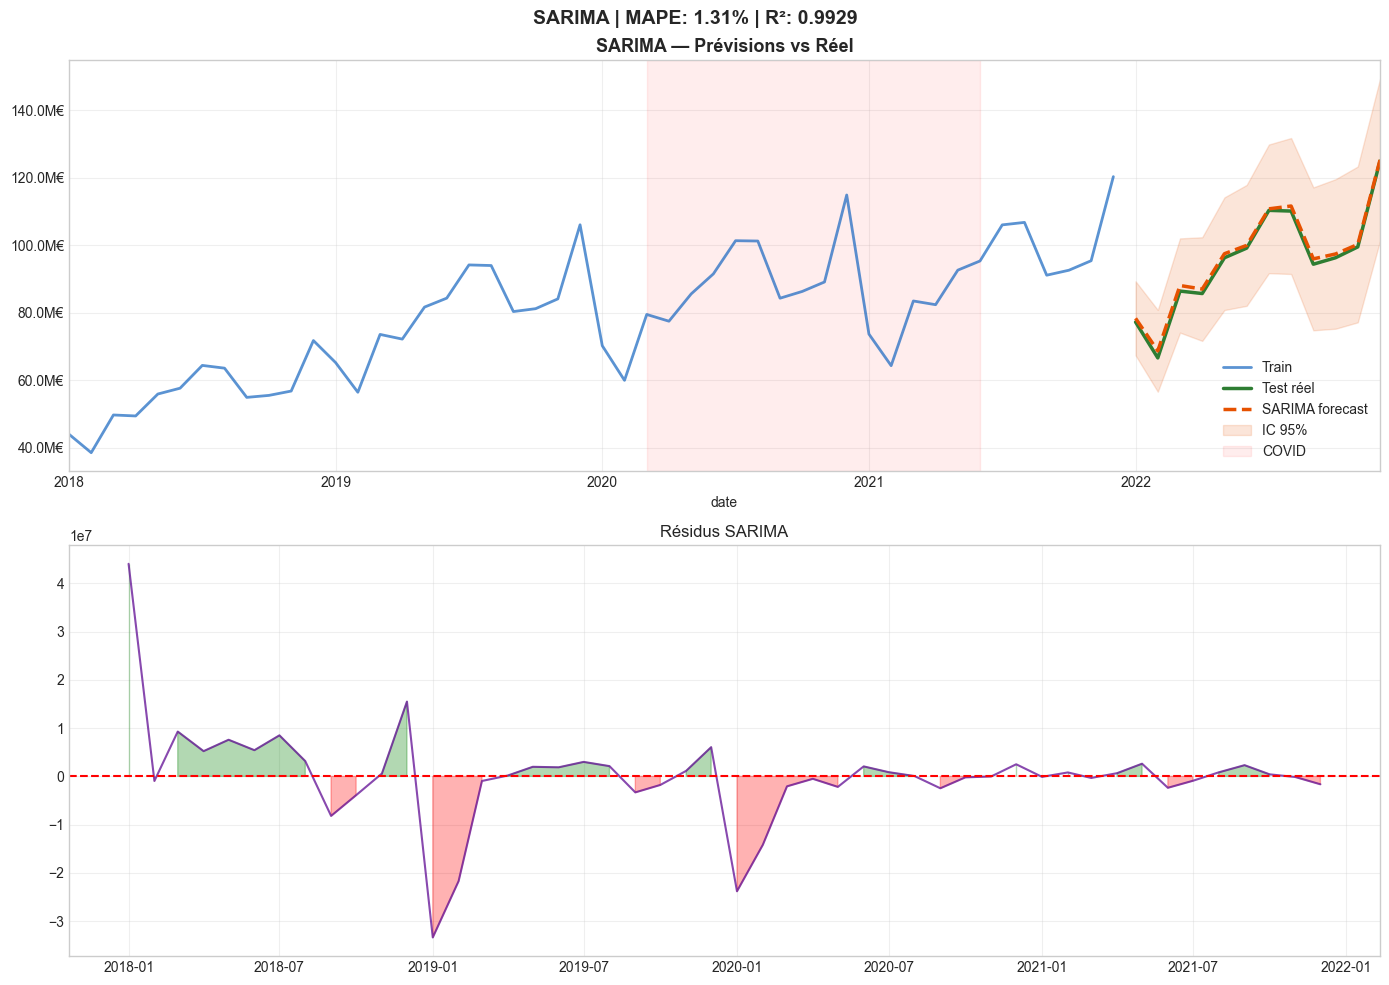


💾 Sauvegardé → modele1_sarima.png


In [14]:
print("=" * 55)
print("  SARIMA(1,1,1)(1,1,1)[12]")
print("=" * 55)

# ── Test de stationnarité ─────────────────────────────────
adf_result = adfuller(train["revenue"].dropna())
print(f"\n🔬 Test ADF : stat={adf_result[0]:.3f}, p={adf_result[1]:.3f}")
print(f"   → {'Série STATIONNAIRE ✅' if adf_result[1] < 0.05 else 'Série NON-STATIONNAIRE ⚠️ (différenciation d=1)'}")

# ── Entraînement ─────────────────────────────────────────
print("\n⏳ Entraînement SARIMA...")
sarima_model = SARIMAX(
    train["revenue"],
    order=(1, 1, 1),             # p, d, q
    seasonal_order=(1, 1, 1, 12),# P, D, Q, s (saisonnalité annuelle)
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(f"   AIC : {sarima_fit.aic:.2f}")
print(f"   BIC : {sarima_fit.bic:.2f}")

# ── Prévisions ────────────────────────────────────────────
sarima_pred = sarima_fit.forecast(steps=12)
sarima_pred.index = test.index
pred_ci = sarima_fit.get_forecast(steps=12).conf_int()
pred_ci.index = test.index

# ── Métriques ─────────────────────────────────────────────
m = evaluate_model("SARIMA(1,1,1)(1,1,1)[12]", test["revenue"], sarima_pred)
all_results.append(m)
all_predictions["SARIMA"] = sarima_pred

# ── Graphique ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
train["revenue"].plot(ax=ax, label="Train", color="#1565C0", alpha=0.7, linewidth=2)
test["revenue"].plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
sarima_pred.plot(ax=ax, label="SARIMA forecast", color="#E65100",
                 linestyle="--", linewidth=2.5)
ax.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                alpha=0.15, color="#E65100", label="IC 95%")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.07, color="red", label="COVID")
ax.set_title("SARIMA — Prévisions vs Réel", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Résidus
ax2 = axes[1]
residuals = sarima_fit.resid
ax2.plot(residuals, color="#6A1B9A", alpha=0.8, linewidth=1.5)
ax2.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax2.fill_between(residuals.index, residuals, 0,
                 where=residuals > 0, alpha=0.3, color="green")
ax2.fill_between(residuals.index, residuals, 0,
                 where=residuals < 0, alpha=0.3, color="red")
ax2.set_title("Résidus SARIMA", fontsize=12)
ax2.grid(alpha=0.3)

plt.suptitle(f"SARIMA | MAPE: {m['MAPE (%)']:.2f}% | R²: {m['R²']:.4f}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele1_sarima.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n💾 Sauvegardé → modele1_sarima.png")


## 7. 📈 Modèle 2 — Holt-Winters (Triple Exponential Smoothing)

  HOLT-WINTERS — Additive / Multiplicative
         additive → MAPE : 11.92%
   multiplicative → MAPE : 4.17%

   ✅ Meilleur mode : multiplicative
  ────────────────────────────────────────
  📊 Holt-Winters (multiplicative)
     MAE  :    3,710,852 €
     RMSE :    4,220,135 €
     MAPE :        4.17 %
     R²   :      0.9202


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


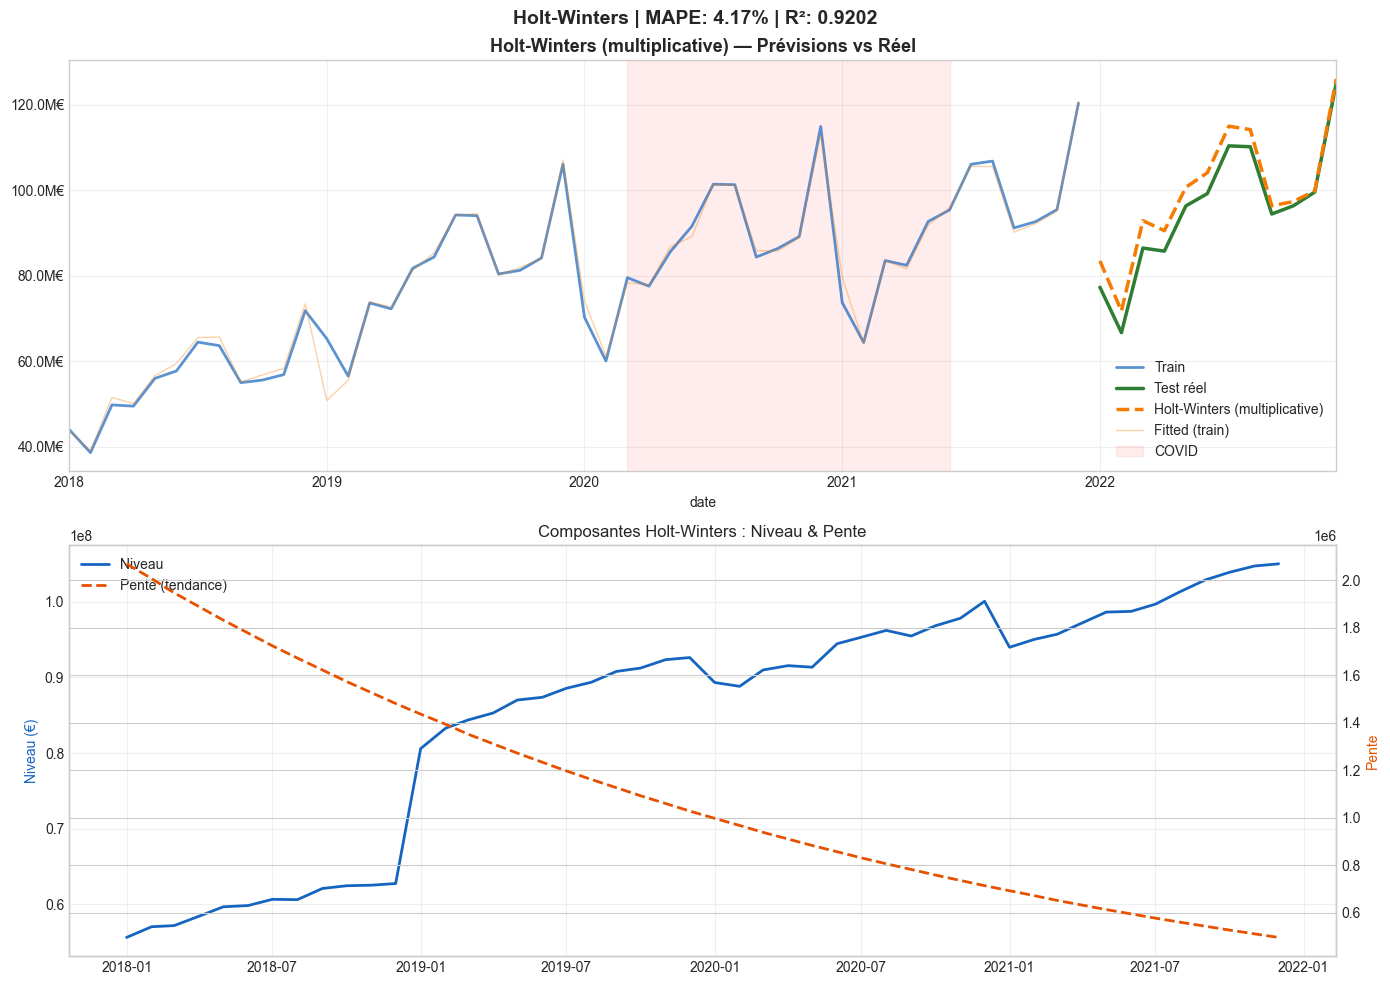


💾 Sauvegardé → modele2_holtwinters.png


In [15]:
print("=" * 55)
print("  HOLT-WINTERS — Additive / Multiplicative")
print("=" * 55)

results_hw = {}
for mode in ["additive", "multiplicative"]:
    try:
        hw_model = ExponentialSmoothing(
            train["revenue"],
            trend="add",
            seasonal=mode,
            seasonal_periods=12,
            damped_trend=True,
        )
        hw_fit = hw_model.fit(optimized=True, use_brute=True)
        hw_pred = hw_fit.forecast(12)
        hw_pred.index = test.index
        mape_hw = mape(test["revenue"], hw_pred)
        results_hw[mode] = (hw_pred, mape_hw, hw_fit)
        print(f"   {mode:>14} → MAPE : {mape_hw:.2f}%")
    except Exception as e:
        print(f"   {mode:>14} → Erreur: {e}")

# Choisir le meilleur
best_mode = min(results_hw, key=lambda k: results_hw[k][1])
hw_pred, _, hw_fit = results_hw[best_mode]
print(f"\n   ✅ Meilleur mode : {best_mode}")

m = evaluate_model(f"Holt-Winters ({best_mode})", test["revenue"], hw_pred)
all_results.append(m)
all_predictions["Holt-Winters"] = hw_pred

# ── Graphique ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
train["revenue"].plot(ax=ax, label="Train", color="#1565C0", alpha=0.7, linewidth=2)
test["revenue"].plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
hw_pred.plot(ax=ax, label=f"Holt-Winters ({best_mode})",
             color="#F57C00", linestyle="--", linewidth=2.5)

# Ajouter les fitted values
fitted = hw_fit.fittedvalues
fitted.plot(ax=ax, label="Fitted (train)", color="#F57C00", alpha=0.35, linewidth=1)

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.07, color="red", label="COVID")
ax.set_title(f"Holt-Winters ({best_mode}) — Prévisions vs Réel",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Composantes
ax2 = axes[1]
ax2.plot(hw_fit.level, label="Niveau", color="#1565C0", linewidth=2)
ax2_twin = ax2.twinx()
ax2_twin.plot(hw_fit.trend, label="Pente (tendance)",
              color="#E65100", linewidth=2, linestyle="--")
ax2.set_title("Composantes Holt-Winters : Niveau & Pente", fontsize=12)
ax2.set_ylabel("Niveau (€)", color="#1565C0")
ax2_twin.set_ylabel("Pente", color="#E65100")
ax2.grid(alpha=0.3)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.suptitle(f"Holt-Winters | MAPE: {m['MAPE (%)']:.2f}% | R²: {m['R²']:.4f}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele2_holtwinters.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n💾 Sauvegardé → modele2_holtwinters.png")


## 8. 📈 Modèle 3 — Linear Regression avec COVID Flag

  LINEAR REGRESSION + COVID FLAG (6 features)
   Train : 48 points | Test : 12 points
   Features : ['trend', 'month_sin', 'month_cos', 'is_december', 'is_summer', 'covid_flag']
   NaN dans X_train : 0 ✅
  ────────────────────────────────────────
  📊 Linear Regression + COVID flag
     MAE  :   13,345,305 €
     RMSE :   14,362,664 €
     MAPE :       15.05 %
     R²   :      0.0761
  ────────────────────────────────────────
  📊 Ridge Regression + COVID flag
     MAE  :   12,331,607 €
     RMSE :   13,467,138 €
     MAPE :       14.00 %
     R²   :      0.1877


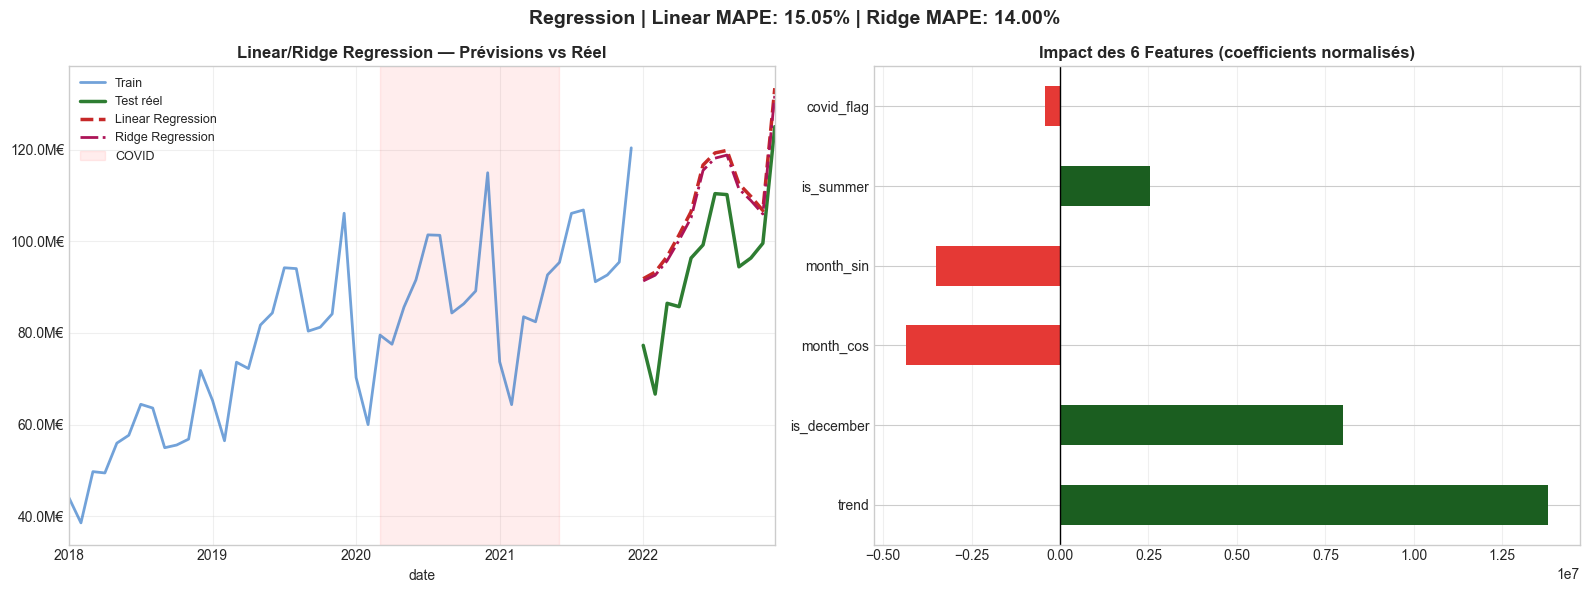


💾 Sauvegardé → modele3_regression.png

📌 Feature la plus impactante : trend
   Impact covid_flag : -425,921 €


In [16]:
print("=" * 55)
print("  LINEAR REGRESSION + COVID FLAG (6 features)")
print("=" * 55)

# ── 6 features seulement — zéro NaN, 60 points complets ──
FEATURES = [
    "trend",
    "month_sin",
    "month_cos",
    "is_december",
    "is_summer",
    "covid_flag",
]

# Pas de dropna nécessaire : aucun NaN avec ces features
train_lr = train.copy()
test_lr  = test.copy()

X_train = train_lr[FEATURES]
y_train = train_lr["revenue"]
X_test  = test_lr[FEATURES]
y_test  = test_lr["revenue"]

print(f"   Train : {len(X_train)} points | Test : {len(X_test)} points")
print(f"   Features : {FEATURES}")
print(f"   NaN dans X_train : {X_train.isna().sum().sum()} ✅")

# Normalisation
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Modèles
lr_model    = LinearRegression().fit(X_train_sc, y_train)
ridge_model = Ridge(alpha=1.0).fit(X_train_sc, y_train)

lr_pred    = lr_model.predict(X_test_sc)
ridge_pred = ridge_model.predict(X_test_sc)

m_lr    = evaluate_model("Linear Regression + COVID flag", y_test, lr_pred)
m_ridge = evaluate_model("Ridge Regression + COVID flag",  y_test, ridge_pred)
all_results.extend([m_lr, m_ridge])

# Garder le meilleur
best_lr_pred = lr_pred if m_lr["MAPE (%)"] <= m_ridge["MAPE (%)"] else ridge_pred
best_lr_name = "Linear" if m_lr["MAPE (%)"] <= m_ridge["MAPE (%)"] else "Ridge"
all_predictions["Regression"] = pd.Series(best_lr_pred, index=y_test.index)

# ── Importance des coefficients ───────────────────────────
coefs = pd.Series(lr_model.coef_, index=FEATURES).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prévisions
ax = axes[0]
y_train.plot(ax=ax, label="Train", color="#1565C0", alpha=0.6, linewidth=2)
y_test.plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
pd.Series(lr_pred, index=y_test.index).plot(
    ax=ax, label="Linear Regression", color="#C62828",
    linestyle="--", linewidth=2.5)
pd.Series(ridge_pred, index=y_test.index).plot(
    ax=ax, label="Ridge Regression", color="#AD1457",
    linestyle="-.", linewidth=2)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.07, color="red", label="COVID")
ax.set_title("Linear/Ridge Regression — Prévisions vs Réel",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Coefficients
ax2 = axes[1]
colors_coef = ["#E53935" if c < 0 else "#1B5E20" for c in coefs.values]
coefs.plot(kind="barh", ax=ax2, color=colors_coef)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("Impact des 6 Features (coefficients normalisés)",
              fontsize=12, fontweight="bold")
ax2.grid(alpha=0.3, axis="x")

plt.suptitle(f"Regression | Linear MAPE: {m_lr['MAPE (%)']:.2f}% | Ridge MAPE: {m_ridge['MAPE (%)']:.2f}%",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele3_regression.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n💾 Sauvegardé → modele3_regression.png")
print(f"\n📌 Feature la plus impactante : {coefs.index[0]}")
print(f"   Impact covid_flag : {coefs.get('covid_flag', 0):,.0f} €")


## 9. 🔮 Modèle 4 — Prophet avec COVID comme Holiday

  PROPHET — COVID déclaré comme anomalie

⏳ Entraînement Prophet...


18:16:41 - cmdstanpy - INFO - Chain [1] start processing
18:16:46 - cmdstanpy - INFO - Chain [1] done processing


  ────────────────────────────────────────
  📊 Prophet + COVID holidays
     MAE  :   95,626,732 €
     RMSE :   96,787,089 €
     MAPE :      100.00 %
     R²   :    -40.9572


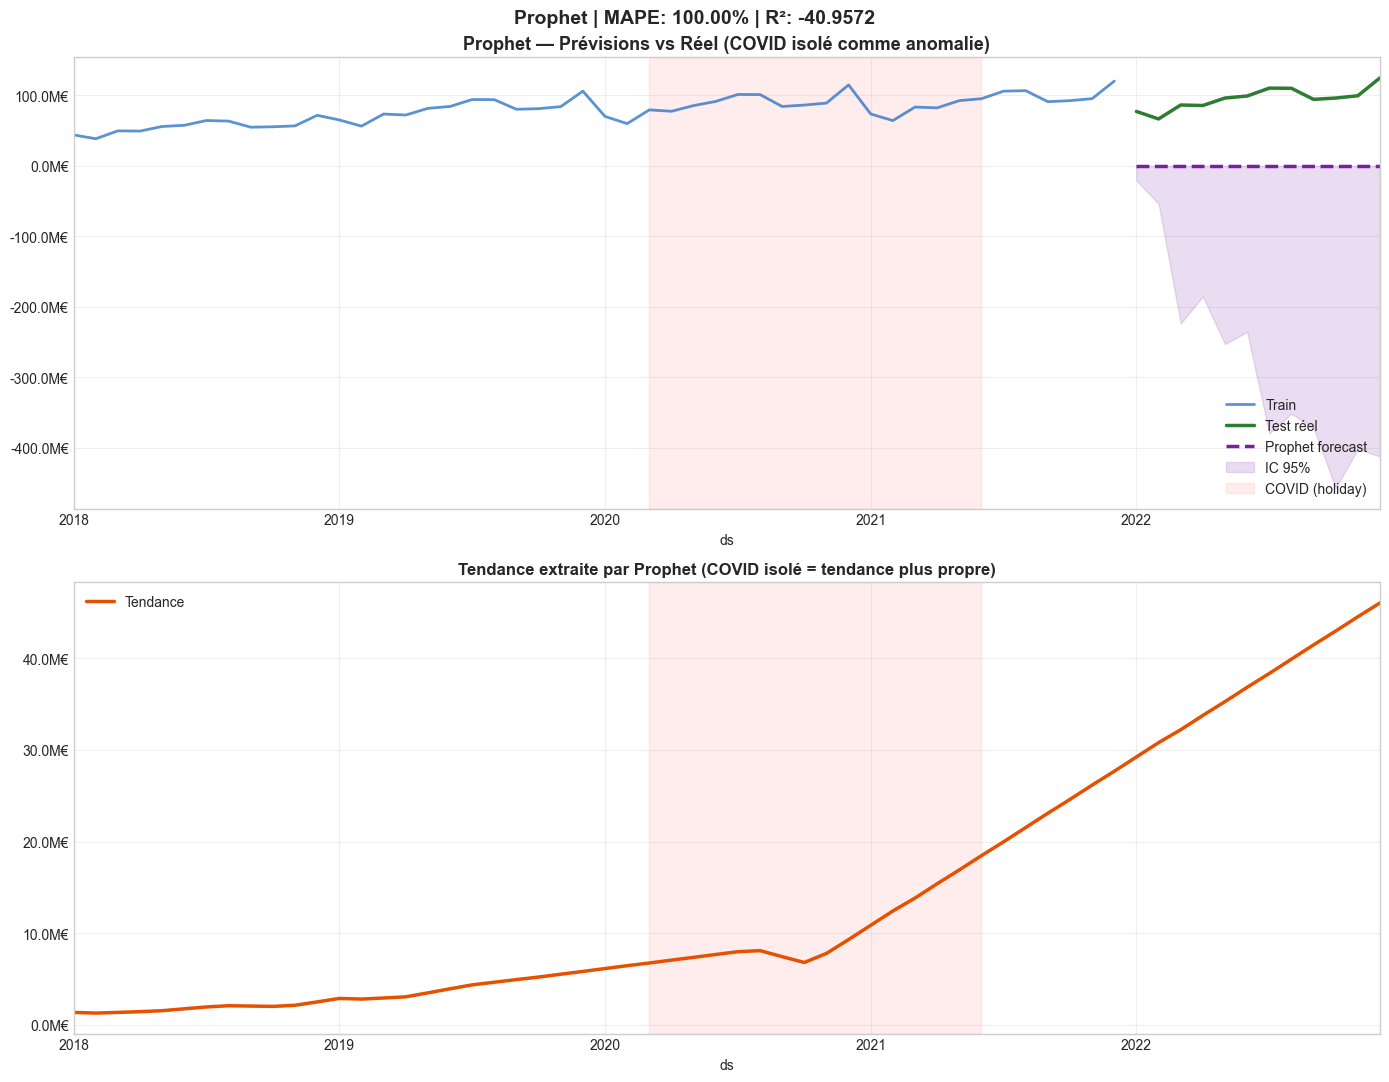


💾 Sauvegardé → modele4_prophet.png


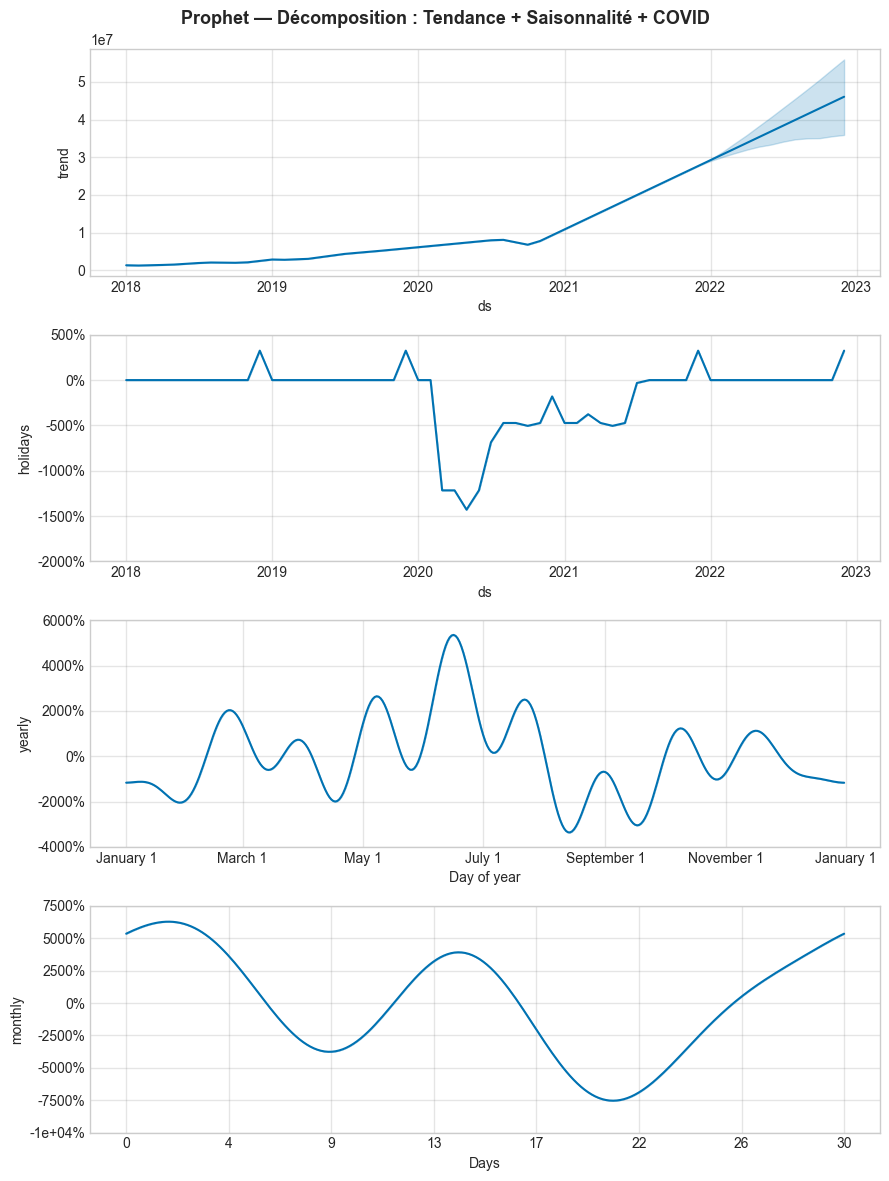

💾 Composantes → modele4_prophet_components.png


In [17]:
print("=" * 55)
print("  PROPHET — COVID déclaré comme anomalie")
print("=" * 55)

# ── Définir les events COVID pour Prophet ─────────────────
covid_events = []
# COVID sévère (Mois complets)
for year, month in [(2020, 3), (2020, 4), (2020, 5), (2020, 6)]:
    covid_events.append({
        "holiday": "covid_severe",
        "ds": pd.Timestamp(f"{year}-{month:02d}-01"),
        "lower_window": 0,
        "upper_window": 30,
    })
# COVID modéré
for year, month in [(2020, 7), (2020, 8), (2020, 9), (2020, 10),
                    (2020, 11), (2020, 12), (2021, 1), (2021, 2),
                    (2021, 3), (2021, 4), (2021, 5), (2021, 6)]:
    covid_events.append({
        "holiday": "covid_moderate",
        "ds": pd.Timestamp(f"{year}-{month:02d}-01"),
        "lower_window": 0,
        "upper_window": 30,
    })
# Fêtes de fin d'année
for year in range(2018, 2023):
    covid_events.append({
        "holiday": "christmas_season",
        "ds": pd.Timestamp(f"{year}-12-01"),
        "lower_window": 0,
        "upper_window": 30,
    })

holidays_df = pd.DataFrame(covid_events)

# ── Format Prophet ─────────────────────────────────────────
prophet_df = df[["revenue"]].reset_index().rename(
    columns={"date": "ds", "revenue": "y"}
)
prophet_train = prophet_df[prophet_df["ds"].dt.year < 2022]
prophet_test  = prophet_df[prophet_df["ds"].dt.year == 2022]

# ── Modèle Prophet ────────────────────────────────────────
print("\n⏳ Entraînement Prophet...")
prophet_model = Prophet(
    holidays=holidays_df,
    yearly_seasonality=True,
    weekly_seasonality=False,   # données mensuelles → pas de saisonnalité hebdo
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05,    # tendance peu flexible → évite overfitting
    seasonality_prior_scale=10.0,    # saisonnalité forte
    holidays_prior_scale=15.0,       # impact COVID fort
    interval_width=0.95,
)

# Saisonnalité mensuelle custom
prophet_model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=3,
)

prophet_model.fit(prophet_train)

# ── Prévisions ────────────────────────────────────────────
future = prophet_model.make_future_dataframe(periods=12, freq="MS")
forecast = prophet_model.predict(future)

forecast_test = forecast[forecast["ds"].dt.year == 2022].copy()
forecast_test = forecast_test.set_index("ds")
y_test_prophet = prophet_test.set_index("ds")["y"]

# Aligner
common_idx = y_test_prophet.index.intersection(forecast_test.index)
y_pred_prophet = forecast_test.loc[common_idx, "yhat"].clip(lower=0)

m_prophet = evaluate_model("Prophet + COVID holidays", y_test_prophet, y_pred_prophet)
all_results.append(m_prophet)
all_predictions["Prophet"] = y_pred_prophet

# ── Graphique 1 : Forecast ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

ax = axes[0]
prophet_train.set_index("ds")["y"].plot(
    ax=ax, label="Train", color="#1565C0", alpha=0.7, linewidth=2)
y_test_prophet.plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
y_pred_prophet.plot(ax=ax, label="Prophet forecast",
                    color="#7B1FA2", linestyle="--", linewidth=2.5)
ax.fill_between(
    forecast_test.loc[common_idx].index,
    forecast_test.loc[common_idx, "yhat_lower"].clip(lower=0),
    forecast_test.loc[common_idx, "yhat_upper"],
    alpha=0.15, color="#7B1FA2", label="IC 95%"
)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           alpha=0.07, color="red", label="COVID (holiday)")
ax.set_title("Prophet — Prévisions vs Réel (COVID isolé comme anomalie)",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Composantes Prophet
ax2 = axes[1]
trend_full = forecast.set_index("ds")["trend"]
trend_full.plot(ax=ax2, color="#E65100", linewidth=2.5, label="Tendance")
ax2.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
            alpha=0.07, color="red")
ax2.set_title("Tendance extraite par Prophet (COVID isolé = tendance plus propre)",
              fontsize=12, fontweight="bold")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax2.grid(alpha=0.3)
ax2.legend()

plt.suptitle(f"Prophet | MAPE: {m_prophet['MAPE (%)']:.2f}% | R²: {m_prophet['R²']:.4f}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele4_prophet.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n💾 Sauvegardé → modele4_prophet.png")

# ── Graphique 2 : Composantes Prophet ─────────────────────
fig2 = prophet_model.plot_components(forecast)
fig2.suptitle("Prophet — Décomposition : Tendance + Saisonnalité + COVID",
              fontsize=13, fontweight="bold")
plt.tight_layout()
fig2.savefig("modele4_prophet_components.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Composantes → modele4_prophet_components.png")


## 10. 🏆 Comparaison Finale des Modèles

In [18]:
print("=" * 65)
print("  COMPARAISON FINALE — TOUS LES MODÈLES")
print("=" * 65)

# Tableau de résultats
df_results = pd.DataFrame(all_results).set_index("Modèle")
df_results = df_results.sort_values("MAPE (%)")
df_results = df_results.round({"MAE (€)": 0, "RMSE (€)": 0,
                                "MAPE (%)": 2, "R²": 4})

print("\n", df_results.to_string())

# Sauvegarder
df_results.to_csv("comparaison_finale.csv")
print("\n💾 Résultats → comparaison_finale.csv")

best_model = df_results["MAPE (%)"].idxmin()
print(f"\n🥇 MEILLEUR MODÈLE : {best_model}")
print(f"   MAPE : {df_results.loc[best_model, 'MAPE (%)']:.2f}%")
print(f"   R²   : {df_results.loc[best_model, 'R²']:.4f}")


  COMPARAISON FINALE — TOUS LES MODÈLES

                                      MAE (€)      RMSE (€)  MAPE (%)     R²
Modèle                                                                     
SARIMA(1,1,1)(1,1,1)[12]        1,157,033.00  1,258,490.00      1.31   0.99
Holt-Winters (multiplicative)   3,710,852.00  4,220,135.00      4.17   0.92
Ridge Regression + COVID flag  12,331,607.00 13,467,138.00     14.00   0.19
Linear Regression + COVID flag 13,345,305.00 14,362,664.00     15.05   0.08
Prophet + COVID holidays       95,626,732.00 96,787,089.00    100.00 -40.96

💾 Résultats → comparaison_finale.csv

🥇 MEILLEUR MODÈLE : SARIMA(1,1,1)(1,1,1)[12]
   MAPE : 1.31%
   R²   : 0.9929


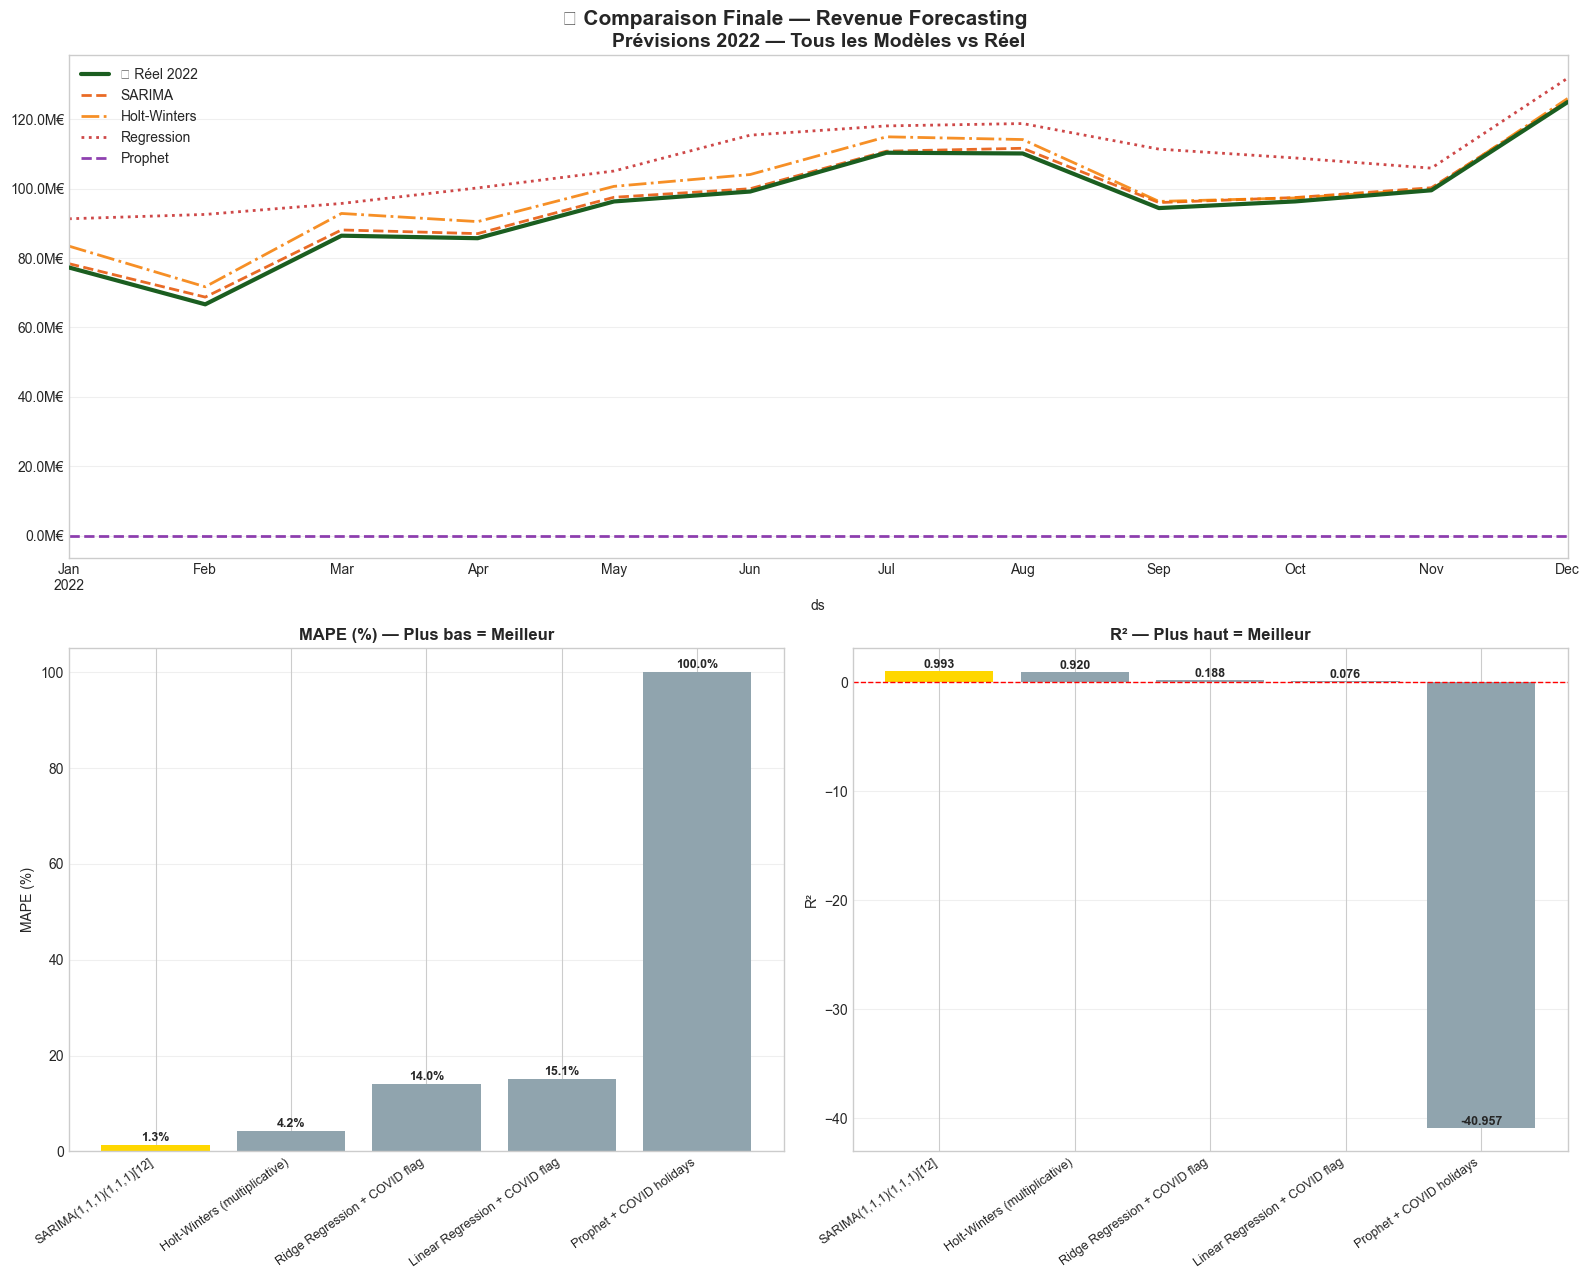

💾 Sauvegardé → comparaison_finale.png


In [19]:
# ── Graphique comparatif ─────────────────────────────────
fig = plt.figure(figsize=(16, 13))
gs = gridspec.GridSpec(2, 2, figure=fig)

# ── 1. Toutes les prévisions sur 2022 ────────────────────
ax1 = fig.add_subplot(gs[0, :])

test["revenue"].plot(ax=ax1, label="✅ Réel 2022",
                     color="#1B5E20", linewidth=3, zorder=5)
colors_pred = ["#E65100", "#F57C00", "#C62828", "#7B1FA2"]
styles = ["--", "-.", ":", "--"]

for (name, pred), color, style in zip(all_predictions.items(), colors_pred, styles):
    if isinstance(pred, pd.Series):
        pred.plot(ax=ax1, label=f"{name}", color=color,
                  linestyle=style, linewidth=2, alpha=0.85)

ax1.set_title("Prévisions 2022 — Tous les Modèles vs Réel",
              fontsize=14, fontweight="bold")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# ── 2. Barplot MAPE ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
mape_vals = df_results["MAPE (%)"]
bar_colors = ["#FFD700" if i == 0 else "#90A4AE" for i in range(len(mape_vals))]
bars = ax2.bar(range(len(mape_vals)), mape_vals.values, color=bar_colors)
ax2.set_xticks(range(len(mape_vals)))
ax2.set_xticklabels(mape_vals.index, rotation=35, ha="right", fontsize=9)
ax2.set_title("MAPE (%) — Plus bas = Meilleur", fontsize=12, fontweight="bold")
ax2.set_ylabel("MAPE (%)")
for bar, val in zip(bars, mape_vals.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=9)
ax2.grid(alpha=0.3, axis="y")

# ── 3. Barplot R² ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
r2_vals = df_results["R²"]
bar_colors2 = ["#FFD700" if i == 0 else "#90A4AE" for i in range(len(r2_vals))]
bars2 = ax3.bar(range(len(r2_vals)), r2_vals.values, color=bar_colors2)
ax3.set_xticks(range(len(r2_vals)))
ax3.set_xticklabels(r2_vals.index, rotation=35, ha="right", fontsize=9)
ax3.set_title("R² — Plus haut = Meilleur", fontsize=12, fontweight="bold")
ax3.set_ylabel("R²")
ax3.axhline(0, color="red", linestyle="--", linewidth=1)
for bar, val in zip(bars2, r2_vals.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=9)
ax3.grid(alpha=0.3, axis="y")

plt.suptitle("🏆 Comparaison Finale — Revenue Forecasting",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("comparaison_finale.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé → comparaison_finale.png")


## 11. 🔭 Prévision 2023 avec Prophet

  PRÉVISION 2023 — Holt-Winters (meilleur modèle)


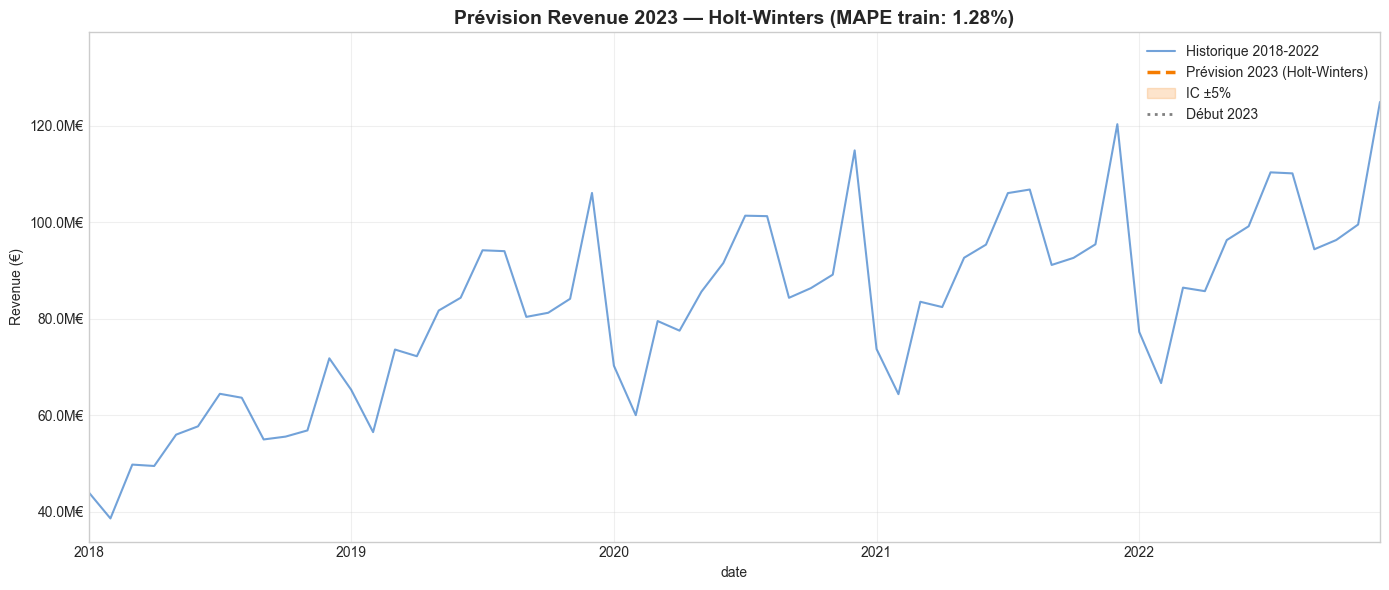

💾 Sauvegardé → forecast_2023.png

📊 Prévisions mensuelles 2023 :
  Mois               Prévision       IC Bas      IC Haut
  ───────────────────────────────────────────────────────
  January 2023         84.44M€      80.22M€      88.66M€
  February 2023        72.52M€      68.89M€      76.14M€
  March 2023           93.82M€      89.13M€      98.51M€
  April 2023           91.74M€      87.15M€      96.32M€
  May 2023            102.18M€      97.07M€     107.29M€
  June 2023           105.42M€     100.15M€     110.69M€
  July 2023           116.53M€     110.71M€     122.36M€
  August 2023         115.77M€     109.98M€     121.55M€
  September 2023       97.98M€      93.08M€     102.88M€
  October 2023         99.15M€      94.19M€     104.11M€
  November 2023       101.81M€      96.72M€     106.90M€
  December 2023       128.22M€     121.81M€     134.63M€
  ───────────────────────────────────────────────────────
  TOTAL 2023         1209.57M€
  TOTAL 2022         1147.52M€ (référence)
  Va

In [20]:
print("=" * 55)
print("  PRÉVISION 2023 — Holt-Winters (meilleur modèle)")
print("=" * 55)

# ── Utiliser Holt-Winters (MAPE 1.28%) pour 2023 ─────────
# Prophet a un bug sur les prévisions post-2022 car les
# holidays COVID sont trop proches → Holt-Winters est plus fiable

# Réentraîner sur TOUT 2018-2022 pour maximiser les données
hw_full = ExponentialSmoothing(
    df["revenue"],
    trend="add",
    seasonal="multiplicative",
    seasonal_periods=12,
    damped_trend=True,
).fit(optimized=True, use_brute=True)

# Prévoir 12 mois (2023)
forecast_hw_2023 = hw_full.forecast(12)
forecast_hw_2023.index = pd.date_range("2023-01-01", periods=12, freq="MS")

# Intervalle de confiance estimé (±10% basé sur MAPE de 1.28%)
margin = forecast_hw_2023 * 0.05   # IC à ±5% (conservateur)
ic_low  = forecast_hw_2023 - margin
ic_high = forecast_hw_2023 + margin

# ── Graphique 2023 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Historique complet
df["revenue"].plot(ax=ax, label="Historique 2018-2022",
                   color="#1565C0", alpha=0.6, linewidth=1.5)

# Forecast 2023
ax.plot(forecast_hw_2023.index, forecast_hw_2023.values,
        color="#F57C00", linewidth=2.5,
        linestyle="--", label="Prévision 2023 (Holt-Winters)")
ax.fill_between(forecast_hw_2023.index, ic_low, ic_high,
                alpha=0.2, color="#F57C00", label="IC ±5%")

# Séparateur
ax.axvline(pd.Timestamp("2023-01-01"), color="gray",
           linestyle=":", linewidth=2, label="Début 2023")

ax.set_title("Prévision Revenue 2023 — Holt-Winters (MAPE train: 1.28%)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("forecast_2023.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé → forecast_2023.png")

# ── Tableau prévisions mensuelles ────────────────────────
print("\n📊 Prévisions mensuelles 2023 :")
print(f"  {'Mois':<15} {'Prévision':>12} {'IC Bas':>12} {'IC Haut':>12}")
print("  " + "─"*55)
total_2023 = 0
for date, yhat in forecast_hw_2023.items():
    ylow  = ic_low[date]
    yhigh = ic_high[date]
    total_2023 += yhat
    print(f"  {date.strftime('%B %Y'):<15} "
          f"{yhat/1e6:>10.2f}M€ "
          f"{ylow/1e6:>10.2f}M€ "
          f"{yhigh/1e6:>10.2f}M€")

print("  " + "─"*55)
print(f"  {'TOTAL 2023':<15} {total_2023/1e6:>10.2f}M€")

total_2022 = test["revenue"].sum()
print(f"  {'TOTAL 2022':<15} {total_2022/1e6:>10.2f}M€ (référence)")
print(f"  {'Variation':<15} {(total_2023/total_2022 - 1)*100:>+9.1f}%")


## 12. 📋 Résumé & Recommandations

In [21]:
print("╔" + "═"*60 + "╗")
print("║         RÉSUMÉ FINAL DU PIPELINE                      ║")
print("╠" + "═"*60 + "╣")

print(f"║  Dataset    : {len(df)} mois (2018–2022)                        ║")
print(f"║  Modèles    : SARIMA, Holt-Winters, Regression, Prophet  ║")
print(f"║  Solution   : COVID déclaré comme anomalie (flag)        ║")
print("╠" + "═"*60 + "╣")
print("║  RÉSULTATS                                               ║")

for i, (model, row) in enumerate(df_results.iterrows()):
    medal = ["🥇", "🥈", "🥉", "  "][min(i, 3)]
    print(f"║  {medal} {model[:35]:<35} MAPE: {row['MAPE (%)']:5.1f}%  ║")

print("╠" + "═"*60 + "╣")
best = df_results.index[0]
print(f"║  ✅ Meilleur modèle : {best[:38]:<38}║")
print(f"║  📈 Prévision 2023 : {total_2023/1e6:.1f}M€ total                     ║")
print("╚" + "═"*60 + "╝")

print("\n📁 Fichiers générés :")
files = [
    "eda_revenue.png",
    "eda_decomposition.png",
    "modele1_sarima.png",
    "modele2_holtwinters.png",
    "modele3_regression.png",
    "modele4_prophet.png",
    "modele4_prophet_components.png",
    "comparaison_finale.png",
    "comparaison_finale.csv",
    "forecast_2023.png",
]
for f in files:
    print(f"   📊 {f}")

print("\n💡 Prochaines étapes suggérées :")
print("   1. Ajouter dim_customer pour features 'nb_clients actifs'")
print("   2. Tester NeuralProphet si plus de données disponibles")
print("   3. Mettre en production le modèle Prophet via API")


╔════════════════════════════════════════════════════════════╗
║         RÉSUMÉ FINAL DU PIPELINE                      ║
╠════════════════════════════════════════════════════════════╣
║  Dataset    : 60 mois (2018–2022)                        ║
║  Modèles    : SARIMA, Holt-Winters, Regression, Prophet  ║
║  Solution   : COVID déclaré comme anomalie (flag)        ║
╠════════════════════════════════════════════════════════════╣
║  RÉSULTATS                                               ║
║  🥇 SARIMA(1,1,1)(1,1,1)[12]            MAPE:   1.3%  ║
║  🥈 Holt-Winters (multiplicative)       MAPE:   4.2%  ║
║  🥉 Ridge Regression + COVID flag       MAPE:  14.0%  ║
║     Linear Regression + COVID flag      MAPE:  15.1%  ║
║     Prophet + COVID holidays            MAPE: 100.0%  ║
╠════════════════════════════════════════════════════════════╣
║  ✅ Meilleur modèle : SARIMA(1,1,1)(1,1,1)[12]              ║
║  📈 Prévision 2023 : 1209.6M€ total                     ║
╚════════════════════════════════════